# Entraînement isolé de PixelRotateOperationModule

Ce notebook entraîne **seulement** l'opération de rotation apprise sur pixels bruts (`PixelRotateOperationModule`), en dehors de tout le pipeline Global Workspace (pas de VAE, pas de GW, pas de tâche digit). Le but est de pouvoir tester rapidement différentes configurations (taille du latent, largeur des canaux conv, learning rate, nombre de steps) et comparer leur courbe de loss et la qualité visuelle des rotations, sans avoir à relancer l'entraînement complet du modèle.

Repères de MSE utiles (cf discussion) :
- tout à 0 / valeur moyenne du pixel : ~0.09-0.11 (trivial, à battre largement)
- VAE MNIST dédié en autoencodage pur (sans rotation) : ~0.009 (plancher indicatif)
- < 0.03 : commence à sortir du bruit ; ~0.01-0.02 : chiffres lisibles ; < 0.01 : bon niveau

In [1]:
import itertools

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from numb_project.data_module import rotate_image_batch
from numb_project.operation_rotation_module import PixelRotateOperationModule

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

device: cpu


/home/lucasc/.cache/pypoetry/virtualenvs/gwnumb-MdIKXIiF-py3.11/lib/python3.11/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [2]:
def infinite_loader(loader: DataLoader):
    """Itère indéfiniment sur un DataLoader (redémarre une nouvelle epoch une fois épuisé)."""
    while True:
        for batch in loader:
            yield batch


def moving_average(values: list[float], window: int = 50) -> list[float]:
    if len(values) < window:
        return values
    cumsum = torch.cumsum(torch.tensor([0.0] + values), dim=0)
    return ((cumsum[window:] - cumsum[:-window]) / window).tolist()

## Repères de référence (baselines)

MSE de quelques prédictions triviales, pour juger si le réseau appris fait mieux que "ne rien apprendre".

In [3]:
eval_loader = DataLoader(mnist_test, batch_size=512, shuffle=True)
eval_images, _ = next(iter(eval_loader))
eval_images = eval_images.to(device)

reference_degrees = 20.0  # même angle que le défaut de PixelRotateOperationModule
eval_angle = torch.full((eval_images.shape[0],), reference_degrees, device=device)
with torch.no_grad():
    eval_target = rotate_image_batch(eval_images, eval_angle)

mse_zero = F.mse_loss(torch.zeros_like(eval_target), eval_target).item()
mse_mean_pixel = F.mse_loss(torch.full_like(eval_target, eval_target.mean()), eval_target).item()
mse_identity = F.mse_loss(eval_images, eval_target).item()

print(f"Repères (MSE sur pixels [0,1], angle fixe {reference_degrees}°) :")
print(f"  tout à 0                      : {mse_zero:.4f}")
print(f"  valeur moyenne du pixel       : {mse_mean_pixel:.4f}")
print(f"  image non tournée (identité)  : {mse_identity:.4f}")

Repères (MSE sur pixels [0,1], angle fixe 20.0°) :
  tout à 0                      : 0.1001
  valeur moyenne du pixel       : 0.0833
  image non tournée (identité)  : 0.0683


## Fonction d'entraînement

Un seul point d'entrée : change `latent_dim`, `channels`, `lr`, `batch_size`, `n_steps` d'un appel à l'autre pour comparer des configurations. Chaque appel crée un modèle neuf et renvoie `(model, loss_history)`.

In [4]:
def train_rotation_model(
    latent_dim: int = 64,
    channels: tuple[int, int] = (16, 32),
    degrees: float = 20.0,
    lr: float = 1e-2,
    batch_size: int = 2056,
    n_steps: int = 5000,
    log_every: int = 100,
    seed: int = 0,
) -> tuple[PixelRotateOperationModule, list[float]]:
    torch.manual_seed(seed)

    model = PixelRotateOperationModule(latent_dim=latent_dim, channels=channels, degrees=degrees).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
    data_iter = infinite_loader(loader)

    config_desc = f"latent_dim={latent_dim}, channels={channels}, degrees={degrees}, lr={lr}, batch_size={batch_size}"
    print(f"Entraînement : {config_desc}")

    loss_history = []
    for step in range(1, n_steps + 1):
        images, _ = next(data_iter)
        images = images.to(device)

        angle_deg = torch.full((images.shape[0],), degrees, device=device)
        with torch.no_grad():
            target = rotate_image_batch(images, angle_deg)

        pred = model(images)
        loss = F.mse_loss(pred, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())
        if step % log_every == 0 or step == n_steps:
            recent = sum(loss_history[-log_every:]) / len(loss_history[-log_every:])
            print(f"  step {step:>6}/{n_steps}  loss={loss.item():.5f}  moyenne récente={recent:.5f}")

    return model, loss_history

## Expérience A (configuration de référence)

In [7]:
model_a, history_a = train_rotation_model(
    latent_dim=64,
    channels=(16, 32),
    lr=1e-3,
    batch_size=2048,
    n_steps=400,
)

Entraînement : latent_dim=64, channels=(16, 32), degrees=20.0, lr=0.001, batch_size=2048
  step    100/400  loss=0.04125  moyenne récente=0.07771
  step    200/400  loss=0.01294  moyenne récente=0.02284
  step    300/400  loss=0.00737  moyenne récente=0.00955
  step    400/400  loss=0.00532  moyenne récente=0.00630


## Expérience B (config alternative à comparer)

Change librement les valeurs ci-dessous (latent_dim, channels, lr, n_steps...) pour tester une autre configuration.

In [ ]:
model_b, history_b = train_rotation_model(
    latent_dim=128,
    channels=(32, 64),
    lr=1e-3,
    batch_size=256,
    n_steps=3000,
)

Entraînement : latent_dim=128, channels=(32, 64), lr=0.001, batch_size=256
  step    200/3000  loss=0.05050  moyenne récente=0.06109
  step    400/3000  loss=0.04151  moyenne récente=0.04697
  step    600/3000  loss=0.03460  moyenne récente=0.03791
  step    800/3000  loss=0.02753  moyenne récente=0.03085
  step   1000/3000  loss=0.02399  moyenne récente=0.02584
  step   1200/3000  loss=0.02218  moyenne récente=0.02264
  step   1400/3000  loss=0.01947  moyenne récente=0.02014
  step   1600/3000  loss=0.01756  moyenne récente=0.01840
  step   1800/3000  loss=0.01648  moyenne récente=0.01699
  step   2000/3000  loss=0.01523  moyenne récente=0.01582
  step   2200/3000  loss=0.01389  moyenne récente=0.01482
  step   2400/3000  loss=0.01393  moyenne récente=0.01414
  step   2600/3000  loss=0.01197  moyenne récente=0.01334
  step   2800/3000  loss=0.01271  moyenne récente=0.01285
  step   3000/3000  loss=0.01251  moyenne récente=0.01226


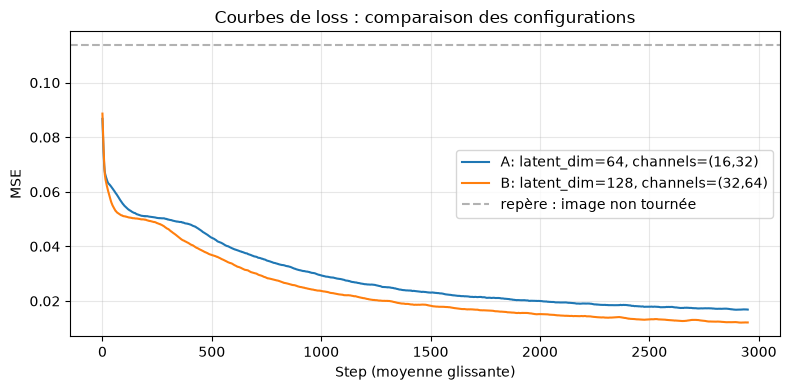

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(moving_average(history_a), label="A: latent_dim=64, channels=(16,32)")
plt.plot(moving_average(history_b), label="B: latent_dim=128, channels=(32,64)")
plt.axhline(mse_identity, linestyle="--", color="gray", alpha=0.6, label="repère : image non tournée")
plt.xlabel("Step (moyenne glissante)")
plt.ylabel("MSE")
plt.title("Courbes de loss : comparaison des configurations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Évaluation qualitative

Choisis le modèle à inspecter (`model_a` ou `model_b`) dans la cellule suivante.

In [8]:
def evaluate_rotation(model, images):
    """MSE de la rotation apprise (une seule application, angle model.degrees)."""
    model.eval()
    angle_tensor = torch.full((images.shape[0],), model.degrees, device=images.device)
    with torch.no_grad():
        target = rotate_image_batch(images, angle_tensor)
        pred = model(images)
    return F.mse_loss(pred, target).item(), pred, target


def apply_rotation_chain(model, images, n: int):
    """Applique n fois l'opération de rotation (pas fixe) sur l'image."""
    with torch.no_grad():
        rotated = images
        for _ in range(n):
            rotated = model(rotated)
    return rotated


def evaluate_rotation_chain(model, images, max_n: int = 12):
    """MSE en fonction du nombre de rotations enchaînées (n x model.degrees), pour voir comment
    l'erreur se dégrade quand on applique l'opération plusieurs fois d'affilée."""
    model.eval()
    ns = list(range(1, max_n + 1))
    mses = []
    for n in ns:
        pred = apply_rotation_chain(model, images, n)
        angle_tensor = torch.full((images.shape[0],), model.degrees * n, device=images.device)
        with torch.no_grad():
            target = rotate_image_batch(images, angle_tensor)
        mses.append(F.mse_loss(pred, target).item())
    return ns, mses


def show_rotation_grid(model, images, n_values_to_show=(1, 4, 8, 12), n_show=6):
    model.eval()
    n_show = min(n_show, images.shape[0])
    fig, axes = plt.subplots(
        1 + len(n_values_to_show), n_show, figsize=(n_show * 1.5, 1.4 * (1 + len(n_values_to_show)))
    )
    for i in range(n_show):
        axes[0, i].imshow(images[i, 0].cpu().numpy(), cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title("original", fontsize=8)
    for row, n in enumerate(n_values_to_show, start=1):
        pred = apply_rotation_chain(model, images, n)
        for i in range(n_show):
            axes[row, i].imshow(pred[i, 0].cpu().numpy(), cmap="gray")
            axes[row, i].axis("off")
            axes[row, i].set_title(f"n={n} ({model.degrees * n:.0f}°)", fontsize=8)
    plt.tight_layout()
    plt.show()


model_to_inspect = model_a  # <- change en model_b pour inspecter l'autre expérience

In [9]:
mse_a, _, _ = evaluate_rotation(model_a, eval_images)
mse_b, _, _ = evaluate_rotation(model_b, eval_images)
print(f"MSE à une seule rotation (angle appris) : A={mse_a:.5f}  B={mse_b:.5f}")

ns_a, chain_mses_a = evaluate_rotation_chain(model_a, eval_images)
ns_b, chain_mses_b = evaluate_rotation_chain(model_b, eval_images)

plt.figure(figsize=(8, 4))
plt.plot(ns_a, chain_mses_a, marker="o", label="A")
plt.plot(ns_b, chain_mses_b, marker="o", label="B")
plt.axhline(mse_identity, linestyle="--", color="gray", alpha=0.6, label="repère : image non tournée")
plt.xlabel("Nombre de rotations enchaînées")
plt.ylabel("MSE")
plt.title("Dégradation avec le nombre de rotations enchaînées")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'model_b' is not defined

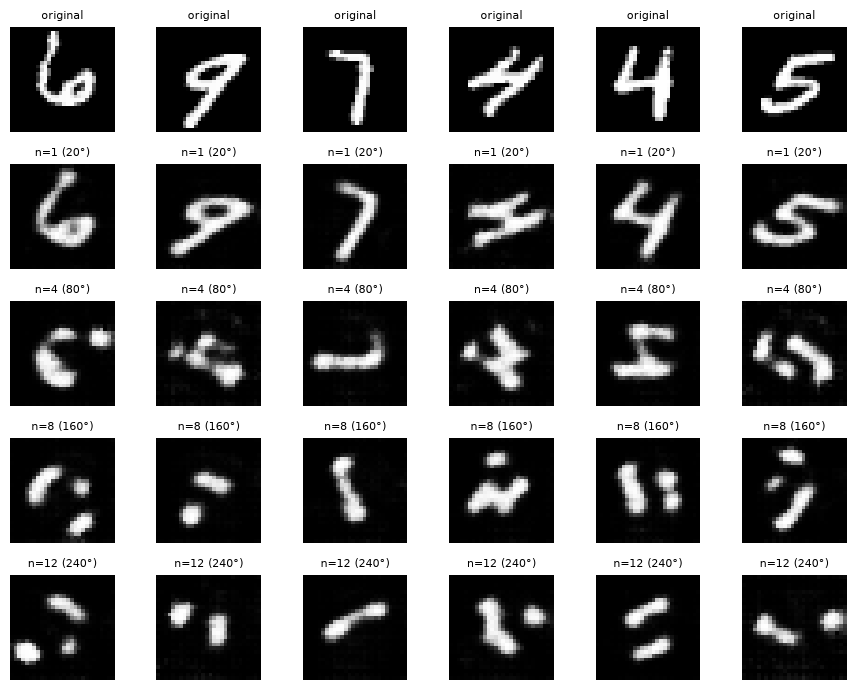

In [10]:
show_rotation_grid(model_to_inspect, eval_images)

## Sauvegarde (optionnel)

Sauvegarde uniquement les poids de `PixelRotateOperationModule` (pas le pipeline complet), pour réutilisation ultérieure une fois une bonne configuration trouvée.

In [ ]:
# torch.save(
#     {
#         "state_dict": model_to_inspect.state_dict(),
#         "latent_dim": model_to_inspect.enc_fc.out_features,
#         "channels": model_to_inspect.channels,
#         "degrees": model_to_inspect.degrees,
#     },
#     "checkpoints/pixel_rotate_experiment.pt",
# )